A Complete pipeline for a model that acts as a chef that can detect multiple input formats and helps with cooking.

In [1]:
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langchain.agents import create_agent
from langchain.tools import tool
from tavily import TavilyClient
from langgraph.checkpoint.memory import InMemorySaver
import base64
load_dotenv()

True

In [2]:
model= ChatMistralAI(model='mistral-medium-2508')

In [3]:
tavily_client= TavilyClient()
@tool
def web_search(query: str) -> str:
    """" Search the web for relevant information. """
    return tavily_client.search(query)

In [18]:
SYSTEM_PROMPT=""""
You are an expert chef, who guides users through cooking process with recipes and cooking tips.

You have access to the following tools:

- web_search: Use this to fetch information from the internet related to cooking recipes and ingredients.

If a user asks your help to make something, provide ingredient list, recipe and cooking tips.
If a user does not have a specific ingredients from the provided list, use the web_search tool to find the alternative ingredients.
For all follow-up queries, use web_search tool if required, but only provide the changes or modifications that are required and not the previous steps.
"""

chef= create_agent(
    model= model,
    tools=[web_search],
    checkpointer=InMemorySaver(),
    system_prompt= SYSTEM_PROMPT
)

In [12]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

image_path = r"C:\Users\Lenovo\Desktop\pizza.jpg"
base64_image = encode_image(image_path)

In [19]:
Question="How to make the pizza that is shown in the image?"
input={'messages':[
    {'role': 'user', 'content': Question},
    {'role': 'user', 'content': [{'type': 'image_url', "image_url": f"data:image/jpg;base64,{base64_image}"}]}
]}
config={'configurable': {'thread_id': '1'}}
response= chef.invoke(input, config)
print(response['messages'][-1].content)

To make the classic **Margherita Pizza** shown in the image, you’ll need the following ingredients and steps. This pizza is known for its simplicity and fresh flavors: tomato sauce, mozzarella cheese, fresh basil, and a crispy crust.

---

## **Ingredient List**

### **For the Dough:**
- 2 cups (250g) all-purpose flour (or 00 flour for a more authentic texture)
- 1 tsp salt
- 1 tsp active dry yeast
- 3/4 cup (180ml) warm water
- 1 tbsp olive oil

### **For the Topping:**
- 1/2 cup (120ml) tomato sauce (preferably San Marzano tomatoes, crushed)
- 2 cups (200g) fresh mozzarella cheese, sliced or shredded
- 4-5 fresh basil leaves
- 2 tbsp olive oil
- Salt to taste
- 1 clove garlic (optional, minced)

---

## **Recipe**

### **1. Prepare the Dough**
1. **Activate the Yeast:** In a small bowl, mix the warm water, yeast, and 1 tsp of sugar. Let it sit for 5-10 minutes until it becomes frothy.
2. **Mix the Dough:** In a large bowl, combine the flour and salt. Add the yeast mixture and olive o

In [20]:
Question="My oven is not working, I have a microwave that I can use. How should I use it?"
input={'messages':[
    {'role': 'user', 'content': Question}
]}
config={'configurable': {'thread_id': '1'}}
response= chef.invoke(input, config)
print(response['messages'][-1].content)

Making pizza in a **microwave** is possible, but the result will be quite different from a traditional oven-baked pizza, especially in terms of crust texture. Microwaves don’t brown or crisp food like an oven, so the crust will be softer. However, you can still enjoy a delicious, cheesy pizza!

Here’s how to adapt the process for a microwave:

---

## **How to Make Pizza in a Microwave**

### **What You’ll Need:**
- Microwave-safe plate or microwave pizza maker (if available)
- Parchment paper (optional, for easier handling)

### **Steps:**

#### 1. **Prepare the Dough**
- Follow the same dough recipe as before, but **roll it out thinner** than usual. A thicker crust will not cook evenly in the microwave.

#### 2. **Pre-Cook the Crust (Optional but Recommended)**
- Microwave the plain dough (without toppings) for **1-2 minutes** on high. This helps firm up the base and prevents a soggy crust.

#### 3. **Add Toppings**
- Spread a thin layer of tomato sauce.
- Add the mozzarella cheese a

{'messages': [HumanMessage(content='How to make the pizza that is shown in the image?', additional_kwargs={}, response_metadata={}, id='bdce64d2-d290-420f-a9d2-41bbf127428d'),
  HumanMessage(content=[{'type': 'image_url', 'image_url': ''}], additional_kwargs={}, response_metadata={}, id='1f3c407c-fa22-42bb-b186-7a3d43e5ed2a'),
  AIMessage(content='To make the classic **Margherita Pizza** shown in the image, you’ll need the following ingredients and steps. This pizza is known for its simplicity and fresh flavors: tomato sauce, mozzarella cheese, fresh basil, and a crispy crust.\n\n---\n\n## **Ingredient List**\n\n### **For the Dough:**\n- 2 cups (250g) all-purpose flour (or 00 flour for a more authentic texture)\n- 1 tsp salt\n- 1 tsp active dry yeast\n- 3/4 cup (180ml) warm water\n- 1 tbsp olive oil\n\n### **For the Topping:**\n- 1/2 cup (120ml) tomato sauce (preferably San Marzano tomatoes, crushed)\n- 2 cups (200g) fresh mozzarella cheese, sliced or shredded\n- 4-5 fresh basil leaves
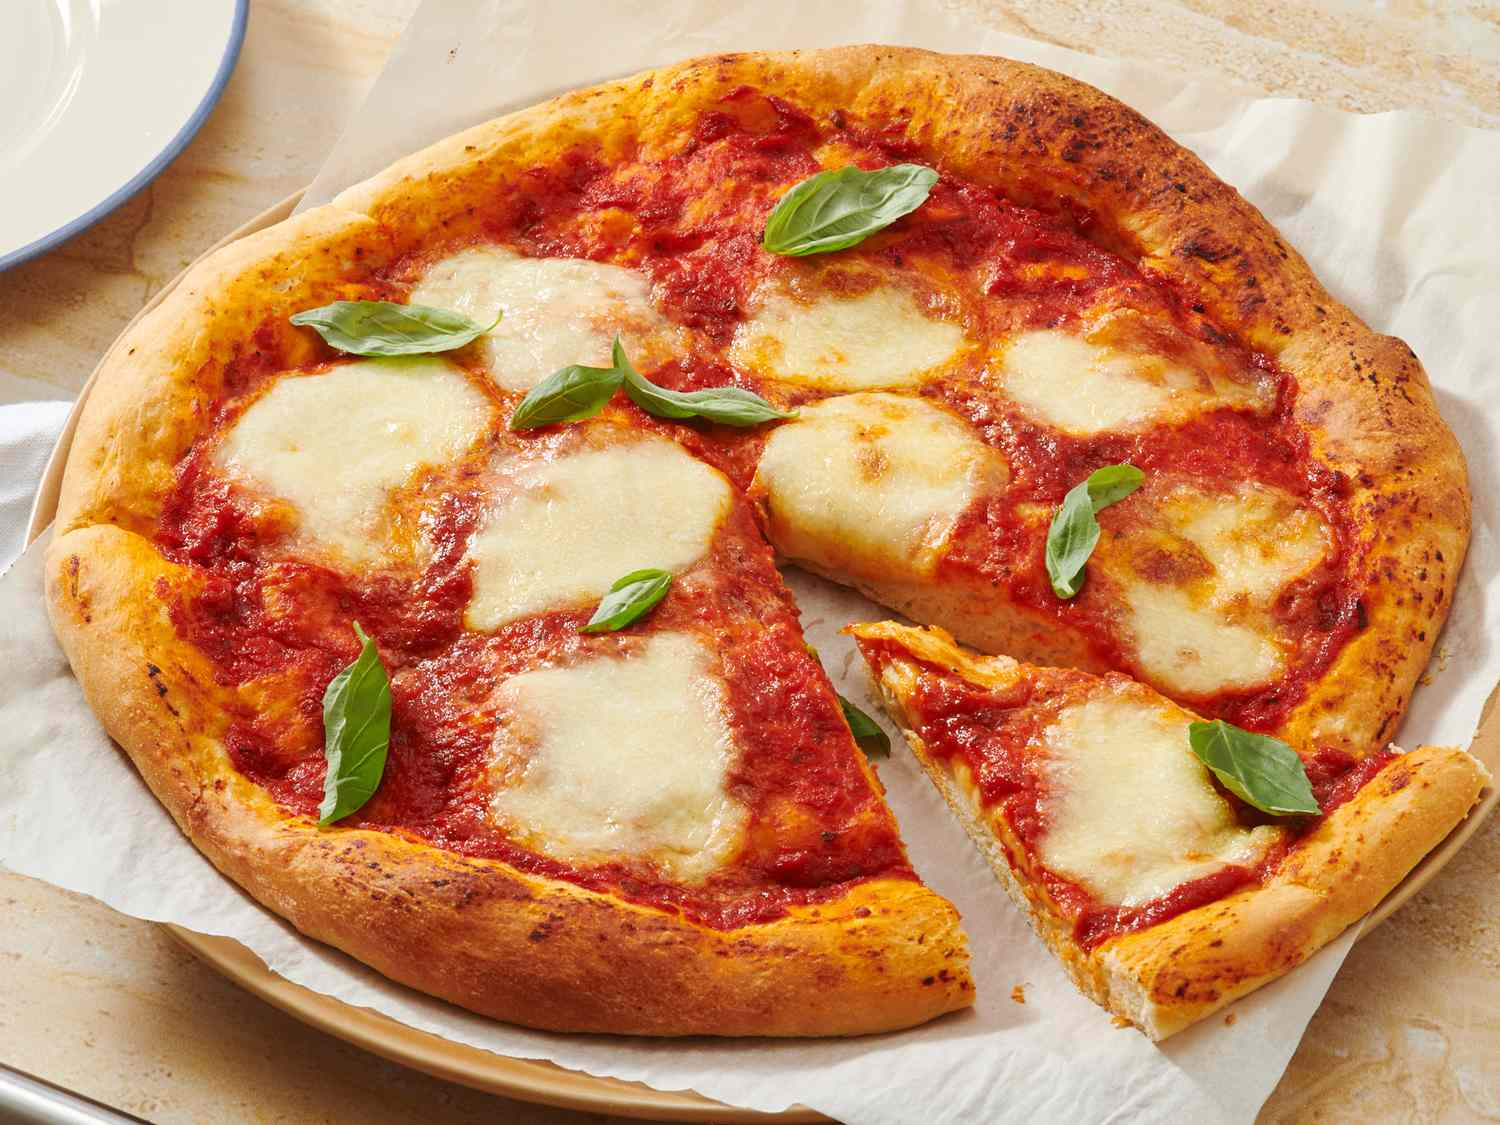

In [21]:
response